## Incident Criticality Visualization

/tmp/ipykernel_9162/4188013076.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


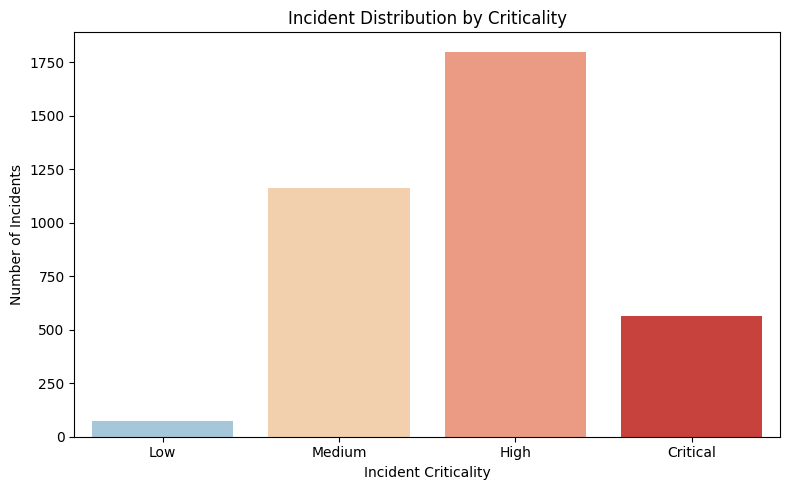

urgency
Low           72
Medium      1164
High        1800
Critical     564
Name: count, dtype: int64

In [4]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "preprocess":
    PROJECT_ROOT = PROJECT_ROOT.parent

ENCODED_INCIDENTS_PATH = PROJECT_ROOT / "data" / "processed" / "incidents_feature_engineered_encoded.csv"
visualization_df = pd.read_csv(ENCODED_INCIDENTS_PATH)

criticality_column = None
for candidate in ["urgency", "incident_criticality"]:
    if candidate in visualization_df.columns:
        criticality_column = candidate
        break

if criticality_column is None:
    raise ValueError(
        "Criticality visualization cannot be created from "
        f"{ENCODED_INCIDENTS_PATH} because it does not contain an 'urgency' or "
        "'incident_criticality' column. Add that field to the exported dataset first."
    )

criticality_order = ["Low", "Medium", "High", "Critical"]
plot_df = visualization_df.copy()
plot_df[criticality_column] = pd.Categorical(
    plot_df[criticality_column],
    categories=criticality_order,
    ordered=True,
)

plt.figure(figsize=(8, 5))
sns.countplot(
    data=plot_df,
    x=criticality_column,
    order=criticality_order,
    palette=["#9ecae1", "#fdd0a2", "#fc9272", "#de2d26"],
)
plt.title("Incident Distribution by Criticality")
plt.xlabel("Incident Criticality")
plt.ylabel("Number of Incidents")
plt.tight_layout()
plt.show()

plot_df[criticality_column].value_counts(dropna=False).sort_index()


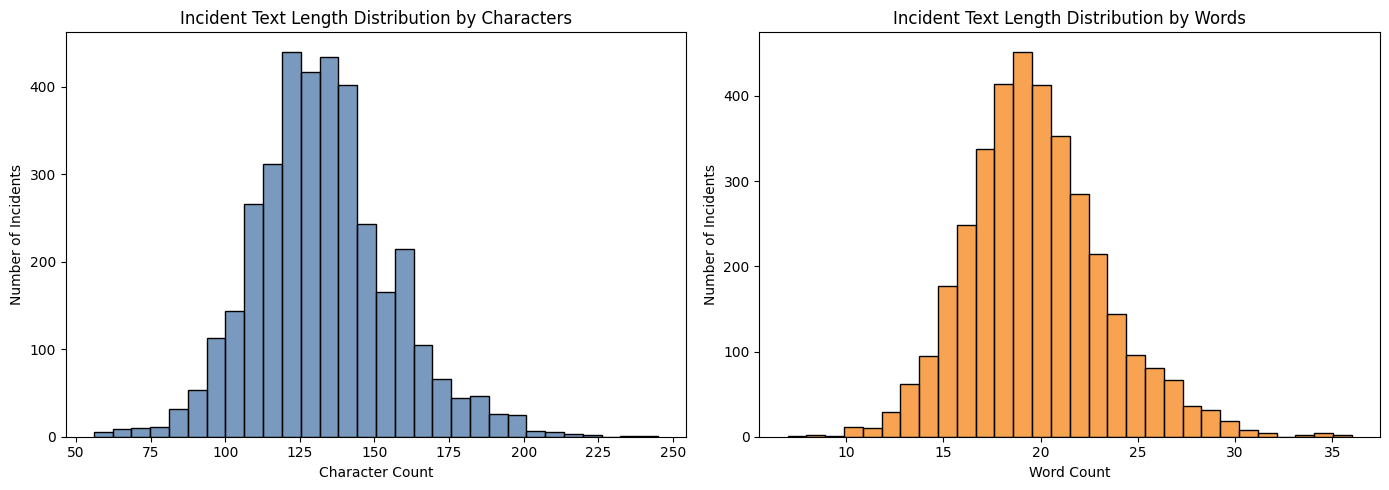

,description_char_length,description_word_count
count,3600.000000,3600.000000
mean,132.677778,19.700833
std,23.107924,3.664629
min,56.000000,7.000000
25%,117.000000,17.000000
50%,131.000000,19.000000
75%,146.000000,22.000000
max,245.000000,36.000000


In [5]:
text_length_df = visualization_df.copy()
text_length_df["incident_description"] = text_length_df["incident_description"].fillna("")
text_length_df["description_char_length"] = text_length_df["incident_description"].str.len()
text_length_df["description_word_count"] = text_length_df["incident_description"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=text_length_df,
    x="description_char_length",
    bins=30,
    color="#4c78a8",
    ax=axes[0],
)
axes[0].set_title("Incident Text Length Distribution by Characters")
axes[0].set_xlabel("Character Count")
axes[0].set_ylabel("Number of Incidents")

sns.histplot(
    data=text_length_df,
    x="description_word_count",
    bins=30,
    color="#f58518",
    ax=axes[1],
)
axes[1].set_title("Incident Text Length Distribution by Words")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Number of Incidents")

plt.tight_layout()
plt.show()

text_length_df[[
    "description_char_length",
    "description_word_count",
]].describe()


## Incident Time Heat Map


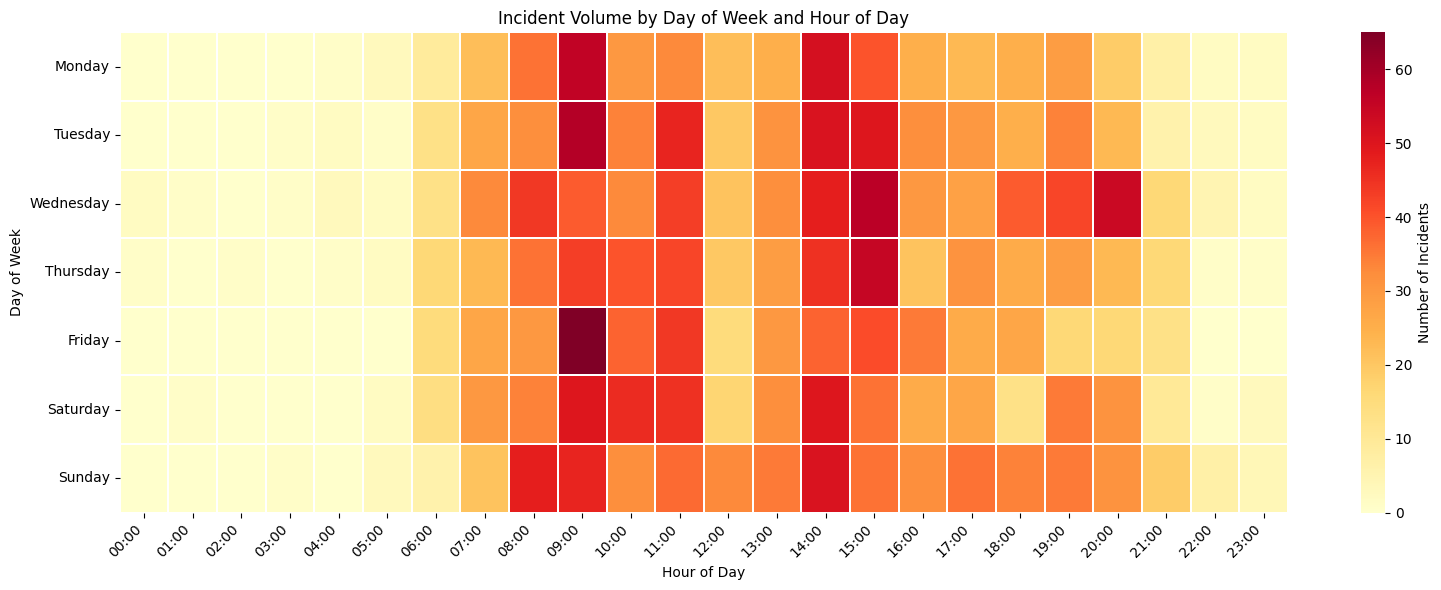

hour_of_day,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_of_week,,,,,,,,,,,,,,,,,,,,,
Monday,0,0,0,0,1,3,9,22,36,56,...,52,40,25,23,25,29,19,7,2,2
Tuesday,0,0,0,1,2,1,13,27,32,58,...,51,50,32,30,25,34,23,6,3,2
Wednesday,2,1,0,1,3,2,13,33,44,39,...,48,57,30,28,39,42,54,16,5,2
Thursday,1,0,1,0,1,2,16,23,36,43,...,45,55,21,31,26,29,23,16,1,1
Friday,0,0,0,0,0,0,15,27,30,65,...,38,41,35,26,27,16,16,13,0,0
Saturday,0,1,0,0,0,2,14,30,34,50,...,50,36,26,27,13,35,31,10,1,3
Sunday,0,0,0,1,0,3,6,21,48,47,...,51,36,32,36,34,35,31,19,7,4


In [6]:
time_heatmap_df = visualization_df.copy()
time_heatmap_df["incident_timestamp"] = pd.to_datetime(
    time_heatmap_df["date"].astype(str) + " " + time_heatmap_df["time"].astype(str),
    format="%Y-%m-%d %I:%M %p",
    errors="coerce",
)

time_heatmap_df = time_heatmap_df.dropna(subset=["incident_timestamp"]).copy()
time_heatmap_df["hour_of_day"] = time_heatmap_df["incident_timestamp"].dt.hour
time_heatmap_df["day_of_week"] = pd.Categorical(
    time_heatmap_df["incident_timestamp"].dt.day_name(),
    categories=[
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday",
    ],
    ordered=True,
)

incident_time_heatmap = pd.crosstab(
    time_heatmap_df["day_of_week"],
    time_heatmap_df["hour_of_day"],
)
incident_time_heatmap = incident_time_heatmap.reindex(
    index=[
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday",
    ],
    columns=range(24),
    fill_value=0,
)

plt.figure(figsize=(16, 6))
sns.heatmap(
    incident_time_heatmap,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Number of Incidents"},
)
plt.title("Incident Volume by Day of Week and Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")
plt.xticks(
    ticks=[hour + 0.5 for hour in range(24)],
    labels=[f"{hour:02d}:00" for hour in range(24)],
    rotation=45,
    ha="right",
)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

incident_time_heatmap


## N-Gram Analysis

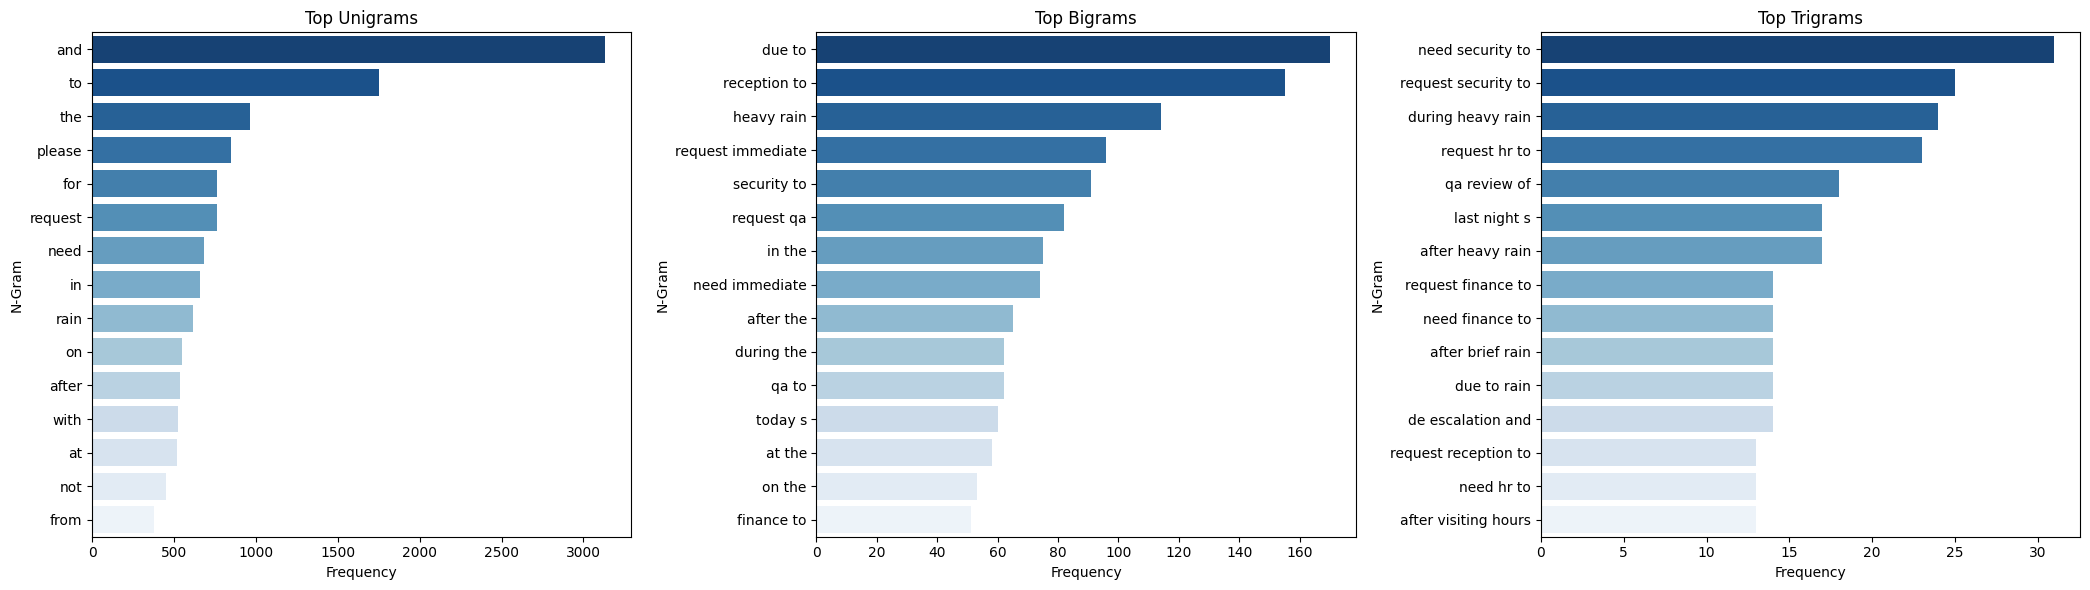

,ngram,count
0,due to,170
1,reception to,155
2,heavy rain,114
3,request immediate,96
4,security to,91
5,request qa,82
6,in the,75
7,need immediate,74
8,after the,65
9,during the,62


In [7]:
import re
from collections import Counter

text_series = visualization_df["incident_description"].fillna("")

def build_ngram_counts(texts: pd.Series, n: int) -> Counter:
    ngram_counter = Counter()
    for text in texts:
        tokens = re.findall(r"\b\w+\b", text.lower())
        if len(tokens) < n:
            continue
        ngrams = [" ".join(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]
        ngram_counter.update(ngrams)
    return ngram_counter

top_n = 15
ngram_config = {
    1: "Top Unigrams",
    2: "Top Bigrams",
    3: "Top Trigrams",
}

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
ngram_tables = {}

for axis, (n, title) in zip(axes, ngram_config.items()):
    ngram_counts = build_ngram_counts(text_series, n)
    top_ngrams = pd.DataFrame(
        ngram_counts.most_common(top_n),
        columns=["ngram", "count"],
    )
    ngram_tables[title] = top_ngrams

    sns.barplot(
        data=top_ngrams,
        x="count",
        y="ngram",
        hue="ngram",
        dodge=False,
        palette="Blues_r",
        legend=False,
        ax=axis,
    )
    axis.set_title(title)
    axis.set_xlabel("Frequency")
    axis.set_ylabel("N-Gram")

plt.tight_layout()
plt.show()

ngram_tables["Top Bigrams"].head(10)
